Load csv and make columns into numpy arrays

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

file_path = "osc_peaks.csv"

df = pd.read_csv(file_path)

time = df["Time(s)"].to_numpy()
ch1 = df["CH1(V)"].to_numpy()
ch2 = df["CH2(V)"].to_numpy()

plotting the loaded data x is time and y is amplitude

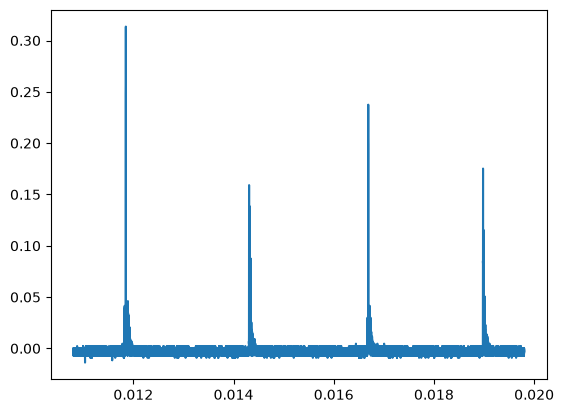

In [2]:
plt.plot(time, ch1)

find index of element closest to a number z in the array ch1

In [3]:
z = 0.0122
diffar = np.absolute(time-z)
index = diffar.argmin()
print("Nearest element to the given values is : ", ch1[index])
print("Index of nearest value is : ", index)

Nearest element to the given values is :  0.0
Index of nearest value is :  155398


zoom in on each peak and locate peaks within cluster

[36347 38950 41573 43540 45595 47192]


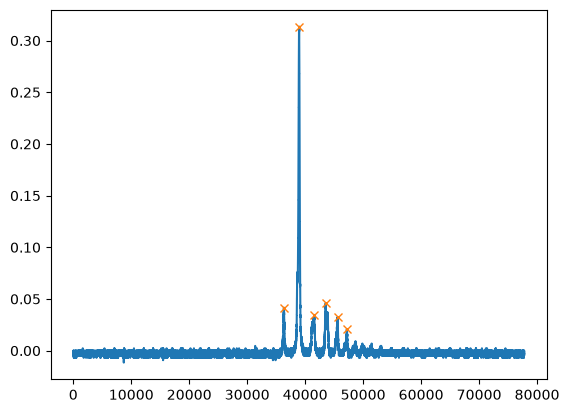

In [4]:
# range t = 0.013 and t =0.0115
first_p =ch1[77620:155398]
first_t = time[77620:155398]
single_peaks, _ = find_peaks(first_p, height = 0.01, width=10, distance=1000)
print(single_peaks)

plt.plot(first_p)
plt.plot(single_peaks, first_p[single_peaks], "x")

-0.00922256
[56783 58506 60315 61930 63515 65239]


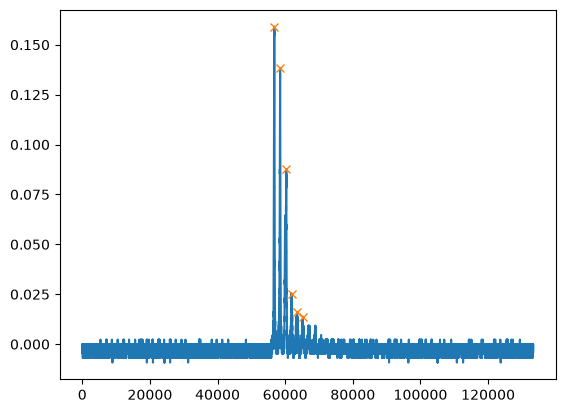

In [5]:
# range t = 0.013 and t =0.0115

second_p = ch1[333176:466509]
second_t = time[333176:466509]
print(second_p.min())
#plt.plot(second_t, second_p)

single_peaks2, _ = find_peaks(second_p, height = 0.01, width=10, distance=1000)
print(single_peaks2)

plt.plot(second_p)
plt.plot(single_peaks2, second_p[single_peaks2], "x")

set thresholds for peak selection and locate only the main peaks

indices of max peaks [116581 389954 654253 908738]
heights of peaks [0.313567  0.1590891 0.2374809 0.1752286]
time values of peaks [0.01185  0.014311 0.016689 0.01898 ]


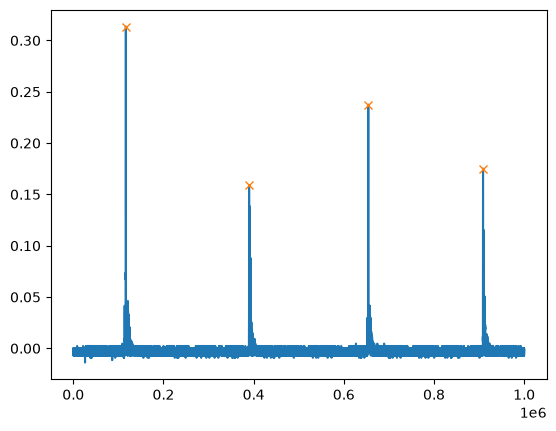

In [6]:
peaked, _ = find_peaks(ch1, height=0.02, width=10, distance=10000)

print("indices of max peaks", peaked)
print("heights of peaks", ch1[peaked])
print("time values of peaks", time[peaked])
#plt.plot(time, ch1)
plt.plot(ch1)
plt.plot(peaked, ch1[peaked], "x")
plt.show()

find distance between peaks 

In [7]:

peak_heights = ch1[peaked]
peak_times = time[peaked]
d_p1_p3 = peak_times[2]- peak_times[0]
d_p2_p4 = peak_times[3]- peak_times[1]
print(" distance between peak 1 and 3", d_p1_p3)
print(" distance between peak 2 and 4", d_p2_p4)

 distance between peak 1 and 3 0.0048389999999999996
 distance between peak 2 and 4 0.0046689999999999995


calculate time scale and convert time axis into frequency space GHz

In [14]:
fsr = 1.5 #Ghz
dt1 = d_p1_p3
dt2 = d_p2_p4
tscale = fsr / dt1 #GHz/s
print(" time scale in GHz/s", tscale)
scan_rate = tscale*1e9 #Hz/s
print("time scale in Hz/s",scan_rate )


 time scale in GHz/s 309.98140111593307
time scale in Hz/s 309981401115.93304


 convert time axis into frequency space GHz and calculate frequancy differences

frequency between peak 1 and 3
1.5 GHz
frequency between peak 2 and 4
1.4473031618102912 GHz
Peak frequencies (GHz):
[0.32517049 1.08803472 1.82517049 2.53533788]
Frequency differences (GHz):
[0.76286423 0.73713577 0.71016739]


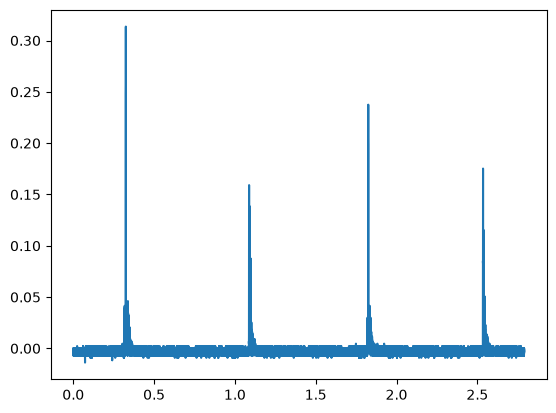

In [25]:
t0 = time[0] 
frequency_GHz = (time - t0) * tscale
plt.plot(frequency_GHz,ch1)

peak_freqs = frequency_GHz[peaked]
freq_diffs = np.diff(peak_freqs)

f_p1_p3 = peak_freqs[2]-peak_freqs[0]
f_p2_p4 = peak_freqs[3]-peak_freqs[1]

print("frequency between peak 1 and 3")
print(f_p1_p3, "GHz")
print("frequency between peak 2 and 4")
print(f_p2_p4 , "GHz")
print("Peak frequencies (GHz):")
print(peak_freqs)
print("Frequency differences (GHz):")
print(freq_diffs)

canvert axis into frequency space Hz and find peak separation in tems of frequency

frequency between peak 1 and 3
1499999999.9999998 Hz
frequency between peak 2 and 4
1447303161.8102915 Hz
Peak frequencies (Hz):
[3.25170490e+08 1.08803472e+09 1.82517049e+09 2.53533788e+09]
Frequency differences (Hz):
[7.62864228e+08 7.37135772e+08 7.10167390e+08]


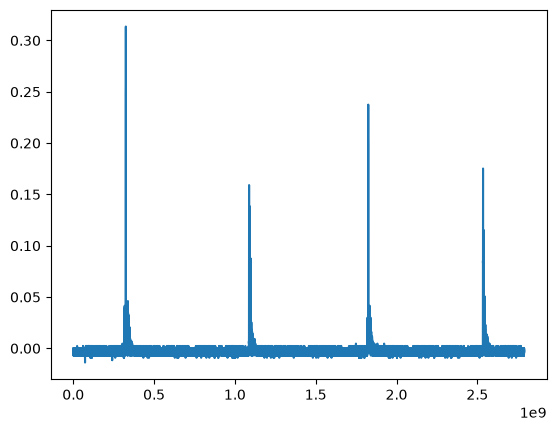

In [27]:
t0 = time[0]
frequency_hz = (time - t0) * scan_rate   
plt.plot(frequency_hz,ch1)

peak_freqs_hz = frequency_hz[peaked]
freq_diffs_hz = np.diff(peak_freqs_hz)

f_p1_p3_hz = peak_freqs_hz[2]-peak_freqs_hz[0]
f_p2_p4_hz = peak_freqs_hz[3]-peak_freqs_hz[1]

print("frequency between peak 1 and 3")
print(f_p1_p3_hz, "Hz")
print("frequency between peak 2 and 4")
print(f_p2_p4_hz , "Hz")


print("Peak frequencies (Hz):")
print(peak_freqs_hz)

print("Frequency differences (Hz):")
print(freq_diffs_hz)
